# Credit Card Transactions Fraud Detection - Exploratory Data Analysis (EDA)

## 1. Problem Statement

Financial fraud is a significant global challenge that continues to escalate. With advanced artificial intelligence being weaponized in fraud tactics, the financial crime landscape is constantly evolving. Banks and financial institutions are leveraging machine learning to detect fraudulent patterns and protect consumer assets.

Credit card fraud specifically refers to the unauthorized use of credit card information to make fraudulent transactions. Modern machine learning algorithms have become critical components of fraud detection systems, enabling real-time analysis and prevention.

## 2. Data Collection

### 2.1 Dataset Overview

The dataset contains legitimate and fraudulent credit card transactions spanning from January 1, 2019 to December 31, 2020. It includes comprehensive transaction and customer information.

**Key Features:**
- Transaction metadata (date/time, amount, merchant, category)
- Customer information (name, gender, age, location)
- Geographic data (customer location, merchant location, distance)
- Device identifiers (credit card number, transaction ID)
- Target variable: is_fraud (0 = Legitimate, 1 = Fraudulent)

### 2.2 Importing Libraries

In [5]:
import pandas as pd              # Data manipulation and analysis
import numpy as np               # Numerical computing
import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns            # Enhanced visualization
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

### 2.3 Loading Data

In [10]:
# Load training and test datasets
data_path = Path('../data/raw')
df_train = pd.read_csv(data_path / 'fraudTrain.csv', index_col=0)
df_test = pd.read_csv(data_path / 'fraudTest.csv', index_col=0)
df_full = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

print(f"\nTraining set: {df_train.shape[0]:,} transactions")
print(f"Test set: {df_test.shape[0]:,} transactions")
print(f"Total: {df_full.shape[0]:,} transactions")
print(f"Features: {df_full.shape[1]} dimensions")


Training set: 1,296,675 transactions
Test set: 555,719 transactions
Total: 1,852,394 transactions
Features: 22 dimensions


In [24]:
print("\nFraud Vs. Legitimate Breakdown:")

print("\nTraining Set:")
train_fraud = df_train['is_fraud'].value_counts()
train_fraud_pct = df_train['is_fraud'].value_counts(normalize=True) * 100
print(f"  Legitimate: {train_fraud.get(0, 0):,} ({train_fraud_pct.get(0, 0):.2f}%)")
print(f"  Fraudulent: {train_fraud.get(1, 0):,} ({train_fraud_pct.get(1, 0):.2f}%)")

print("\nTest Set:")
test_fraud = df_test['is_fraud'].value_counts()
test_fraud_pct = df_test['is_fraud'].value_counts(normalize=True) * 100
print(f"  Legitimate: {test_fraud.get(0, 0):,} ({test_fraud_pct.get(0, 0):.2f}%)")
print(f"  Fraudulent: {test_fraud.get(1, 0):,} ({test_fraud_pct.get(1, 0):.2f}%)")

print("\nFull Dataset:")
full_fraud = df_full['is_fraud'].value_counts()
full_fraud_pct = df_full['is_fraud'].value_counts(normalize=True) * 100
print(f"  Legitimate: {full_fraud.get(0, 0):,} ({full_fraud_pct.get(0, 0):.2f}%)")
print(f"  Fraudulent: {full_fraud.get(1, 0):,} ({full_fraud_pct.get(1, 0):.2f}%)")


Fraud Vs. Legitimate Breakdown:

Training Set:
  Legitimate: 1,289,169 (99.42%)
  Fraudulent: 7,506 (0.58%)

Test Set:
  Legitimate: 553,574 (99.61%)
  Fraudulent: 2,145 (0.39%)

Full Dataset:
  Legitimate: 1,842,743 (99.48%)
  Fraudulent: 9,651 (0.52%)


## 3. Data Overview

In [25]:
print("\nDataset Information")

print(f"\nDataset Shape: {df_full.shape}")
print(f"Rows: {df_full.shape[0]:,} | Columns: {df_full.shape[1]}")

print("\nData Types and Information")
print(df_full.info())

print("\nFirst 5 Rows")
display(df_full.head())


Dataset Information

Dataset Shape: (1852394, 22)
Rows: 1,852,394 | Columns: 22

Data Types and Information
<class 'pandas.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  str    
 1   cc_num                 int64  
 2   merchant               str    
 3   category               str    
 4   amt                    float64
 5   first                  str    
 6   last                   str    
 7   gender                 str    
 8   street                 str    
 9   city                   str    
 10  state                  str    
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    str    
 16  dob                    str    
 17  trans_num              str    
 18  unix_time              int64  
 19  merch_lat              float

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 4. Data Preprocessing

### 4.1 Data Cleaning

In [26]:
print("\nData Quality Assessment")

# 1. Missing Values
print("\n1. Missing Values:")
missing_values = df_full.isnull().sum()
missing_pct = (missing_values / len(df_full) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing_values, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("   No missing values detected")

# 2. Duplicate Rows
print(f"\n2. DUPLICATE ROWS:")
duplicates = df_full.duplicated().sum()
print(f"   Total duplicates: {duplicates} ({duplicates/len(df_full)*100:.2f}%)")
if duplicates > 0:
    print("   WARNING: Duplicates detected")
else:
    print("   No duplicates found")


Data Quality Assessment

1. Missing Values:
   No missing values detected

2. DUPLICATE ROWS:
   Total duplicates: 0 (0.00%)
   No duplicates found


### 4.2 Feature Engineering & Data Transformation

Extract time-based features and calculate distances between customer and merchant locations.

In [27]:
# DateTime Feature Extraction
print("Extracting temporal features...")
df_full['trans_date_trans_time'] = pd.to_datetime(df_full['trans_date_trans_time'])
df_full['hour'] = df_full['trans_date_trans_time'].dt.hour
df_full['day'] = df_full['trans_date_trans_time'].dt.day
df_full['month'] = df_full['trans_date_trans_time'].dt.month
df_full['day_of_week'] = df_full['trans_date_trans_time'].dt.dayofweek

# Customer Age Extraction
print("Calculating customer age...")
df_full['dob'] = pd.to_datetime(df_full['dob'])
df_full['age'] = df_full['trans_date_trans_time'].dt.year - df_full['dob'].dt.year

# Distance Calculation (Haversine Formula)
print("Calculating transaction distance using Haversine formula...")
def calculate_haversine_distance(df):
    """Calculate distance between two geographic points in kilometers"""
    lat1, lon1 = np.radians(df['lat']), np.radians(df['long'])
    lat2, lon2 = np.radians(df['merch_lat']), np.radians(df['merch_long'])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    r = 6371  # Earth's radius in km
    return c * r

df_full['distance_km'] = calculate_haversine_distance(df_full)
print("Feature engineering completed")

Extracting temporal features...
Calculating customer age...
Calculating transaction distance using Haversine formula...
Feature engineering completed


## 5. Descriptive Statistics

In [28]:
print("\nStatistical Summary")

# Display summary statistics
print("\nNumeric Features Summary:")
display(df_full.describe().T)

print("\nFeature Value Counts (Unique Values):")
unique_counts = df_full.nunique().sort_values(ascending=False)
print(unique_counts)


Statistical Summary

Numeric Features Summary:


,count,mean,min,25%,50%,75%,max,std
trans_date_trans_time,1852394,2020-01-20 21:31:46.801827,2019-01-01 00:00:18,2019-07-23 04:13:43.750000,2020-01-02 01:15:31,2020-07-23 12:11:25.250000,2020-12-31 23:59:34,NaN
cc_num,1852394.0,417386038393710400.0,60416207185.0,180042946491150.0,3521417320836166.0,4642255475285942.0,4992346398065154048.0,1309115265318735104.0
amt,1852394.0,70.063567,1.0,9.64,47.45,83.1,28948.9,159.253975
zip,1852394.0,48813.258191,1257.0,26237.0,48174.0,72042.0,99921.0,26881.845966
lat,1852394.0,38.539311,20.0271,34.6689,39.3543,41.9404,66.6933,5.07147
long,1852394.0,-90.227832,-165.6723,-96.798,-87.4769,-80.158,-67.9503,13.747895
city_pop,1852394.0,88643.674509,23.0,741.0,2443.0,20328.0,2906700.0,301487.618344
dob,1852394,1973-10-15 11:05:05.744458,1924-10-30 00:00:00,1962-08-13 00:00:00,1975-11-30 00:00:00,1987-04-23 00:00:00,2005-01-29 00:00:00,NaN
unix_time,1852394.0,1358674218.834364,1325376018.0,1343016823.75,1357089331.0,1374581485.25,1388534374.0,18195081.38756
merch_lat,1852394.0,38.538976,19.027422,34.740122,39.3689,41.956263,67.510267,5.105604



Feature Value Counts (Unique Values):
distance_km              1852394
trans_num                1852394
unix_time                1819583
trans_date_trans_time    1819551
merch_long               1809753
merch_lat                1754157
amt                        60616
street                       999
cc_num                       999
zip                          985
dob                          984
long                         983
lat                          983
city                         906
city_pop                     891
merchant                     693
job                          497
last                         486
first                        355
age                           83
state                         51
day                           31
hour                          24
category                      14
month                         12
day_of_week                    7
is_fraud                       2
gender                         2
dtype: int64


## 6. Data Visualization and Analysis

### 6.1 Target Class Distribution


Target Variable Distribution (is_fraud)

Class   | Count      | Percentage
--------|------------|------------
0 (No)  | 1,842,743  | 99.48%
1 (Yes) | 9,651  | 0.52%

Imbalance Ratio: 0.52% fraudulent transactions


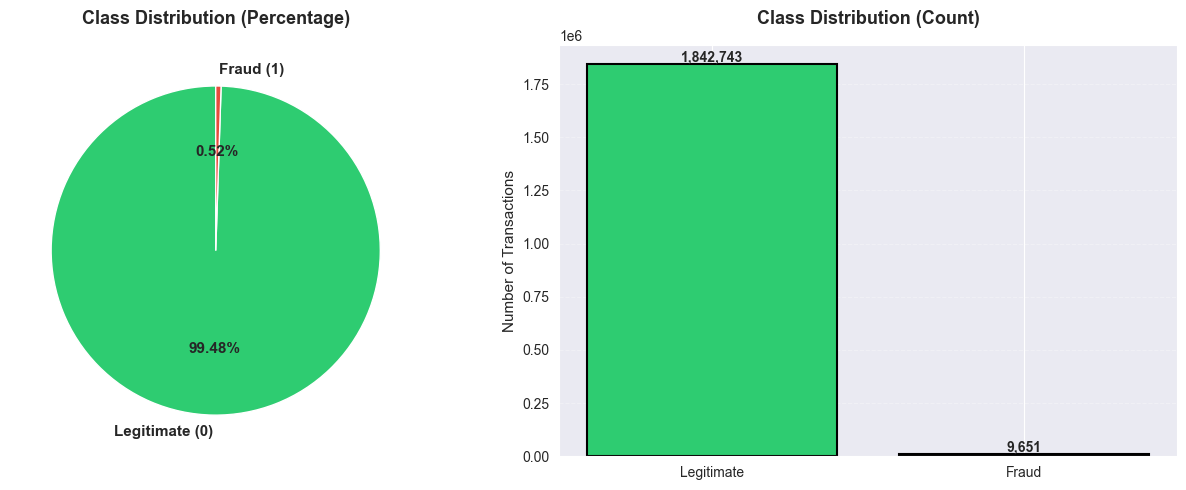

In [30]:
# Target Variable Analysis
print("\nTarget Variable Distribution (is_fraud)")

fraud_counts = df_full['is_fraud'].value_counts()
fraud_pct = df_full['is_fraud'].value_counts(normalize=True) * 100

print(f"\nClass   | Count      | Percentage")
print(f"--------|------------|------------")
print(f"0 (No)  | {fraud_counts[0]:,}  | {fraud_pct[0]:.2f}%")
print(f"1 (Yes) | {fraud_counts[1]:,}  | {fraud_pct[1]:.2f}%")
print(f"\nImbalance Ratio: {fraud_pct[1]:.2f}% fraudulent transactions")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie Chart
colors_pie = ['#2ecc71', '#e74c3c']
axes[0].pie(fraud_counts, labels=['Legitimate (0)', 'Fraud (1)'], 
            autopct='%1.2f%%', colors=colors_pie, startangle=90,
            textprops={'fontsize': 11, 'weight': 'bold'})
axes[0].set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold', pad=15)

# Bar Chart
bars = axes[1].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=colors_pie, edgecolor='black', linewidth=1.5)
axes[1].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Number of Transactions', fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

OBSERVATION: The dataset exhibits severe class imbalance with 99.48% legitimate transactions and only 0.52% fraudulent transactions. This is realistic for real-world fraud data but requires careful handling during model training.

### 6.2 Numerical Features Analysis

In [31]:
# Identify numeric and categorical columns
numeric_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_full.select_dtypes(include=['object']).columns.tolist()

if 'is_fraud' in numeric_cols:
    numeric_cols.remove('is_fraud')

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"\nTotal features: {len(numeric_cols) + len(categorical_cols)}")

Numeric features (15): ['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'hour', 'day', 'month', 'day_of_week', 'age', 'distance_km']

Categorical features (10): ['merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'trans_num']

Total features: 25


#### Transaction Amount Analysis


Transaction Amount Analysis


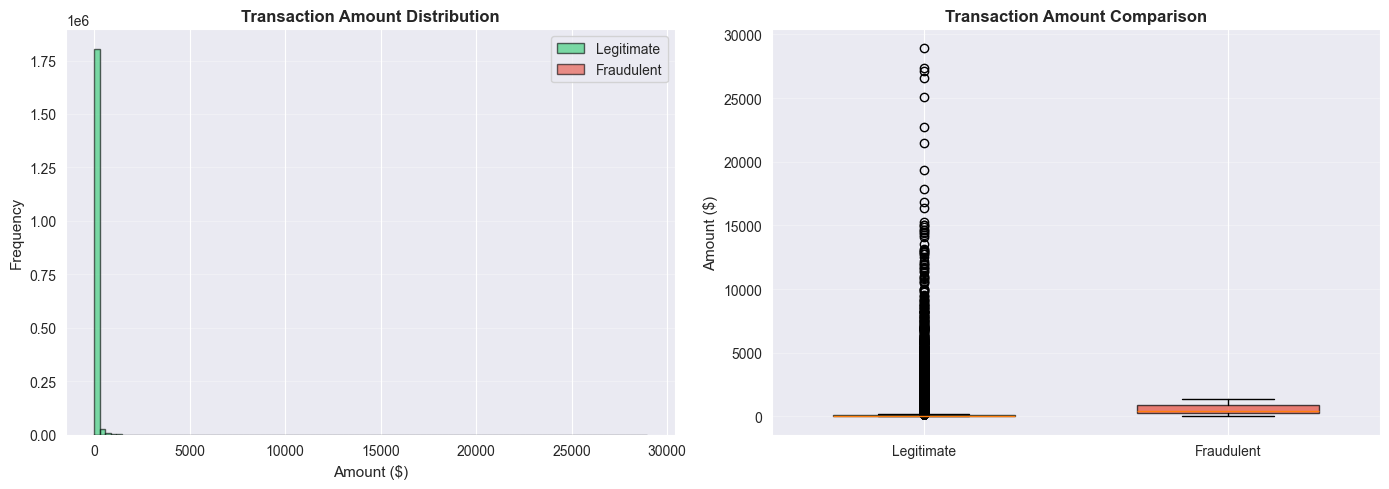


Key Insights:
Legitimate Transactions:
  Mean: $67.65
  Median: $47.24
  Max: $28948.90

Fraudulent Transactions:
  Mean: $530.66
  Median: $390.00
  Max: $1376.04

Fraudsters avoid large transactions to bypass detection systems


In [34]:
print("\nTransaction Amount Analysis")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legit_amt = df_full[df_full['is_fraud'] == 0]['amt']
fraud_amt = df_full[df_full['is_fraud'] == 1]['amt']

axes[0].hist(legit_amt, bins=100, alpha=0.6, label='Legitimate', color='#2ecc71', edgecolor='black')
axes[0].hist(fraud_amt, bins=100, alpha=0.6, label='Fraudulent', color='#e74c3c', edgecolor='black')
axes[0].set_title('Transaction Amount Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

bp = axes[1].boxplot([legit_amt, fraud_amt], labels=['Legitimate', 'Fraudulent'],
                      patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Transaction Amount Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amount ($)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"Legitimate Transactions:")
print(f"  Mean: ${legit_amt.mean():.2f}")
print(f"  Median: ${legit_amt.median():.2f}")
print(f"  Max: ${legit_amt.max():.2f}")
print(f"\nFraudulent Transactions:")
print(f"  Mean: ${fraud_amt.mean():.2f}")
print(f"  Median: ${fraud_amt.median():.2f}")
print(f"  Max: ${fraud_amt.max():.2f}")
print(f"\nFraudsters avoid large transactions to bypass detection systems")

#### Customer Age & Location Analysis


Age & Location Analysis


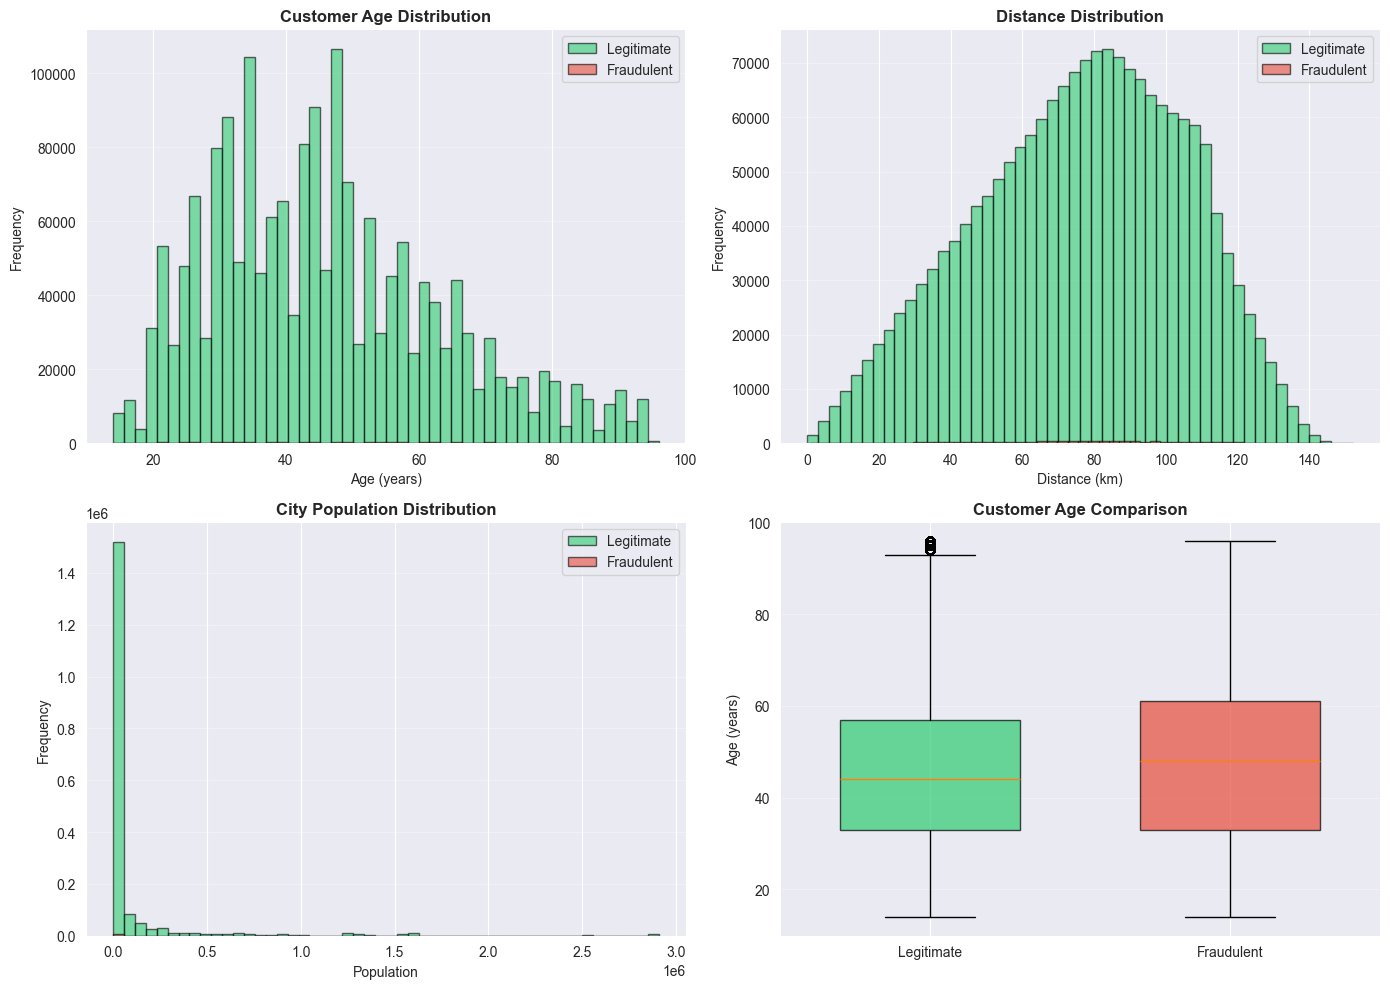


Key Insights:
Age Analysis:
  Legitimate - Mean: 46.2 years, Median: 44.0 years
  Fraudulent - Mean: 48.8 years, Median: 48.0 years
  Older customers tend to be more targeted by fraud

Distance Analysis:
  Both classes show similar distance distributions
  Distance alone is not a strong fraud indicator


In [37]:
print("\nAge & Location Analysis")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

legit_age = df_full[df_full['is_fraud'] == 0]['age'].dropna()
fraud_age = df_full[df_full['is_fraud'] == 1]['age'].dropna()

axes[0, 0].hist(legit_age, bins=50, alpha=0.6, label='Legitimate', color='#2ecc71', edgecolor='black')
axes[0, 0].hist(fraud_age, bins=50, alpha=0.6, label='Fraudulent', color='#e74c3c', edgecolor='black')
axes[0, 0].set_title('Customer Age Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

legit_dist = df_full[df_full['is_fraud'] == 0]['distance_km']
fraud_dist = df_full[df_full['is_fraud'] == 1]['distance_km']

axes[0, 1].hist(legit_dist, bins=50, alpha=0.6, label='Legitimate', color='#2ecc71', edgecolor='black')
axes[0, 1].hist(fraud_dist, bins=50, alpha=0.6, label='Fraudulent', color='#e74c3c', edgecolor='black')
axes[0, 1].set_title('Distance Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Distance (km)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

legit_pop = df_full[df_full['is_fraud'] == 0]['city_pop']
fraud_pop = df_full[df_full['is_fraud'] == 1]['city_pop']

axes[1, 0].hist(legit_pop, bins=50, alpha=0.6, label='Legitimate', color='#2ecc71', edgecolor='black')
axes[1, 0].hist(fraud_pop, bins=50, alpha=0.6, label='Fraudulent', color='#e74c3c', edgecolor='black')
axes[1, 0].set_title('City Population Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Population', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

bp = axes[1, 1].boxplot([legit_age, fraud_age], labels=['Legitimate', 'Fraudulent'],
                         patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('Customer Age Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Age (years)', fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"Age Analysis:")
print(f"  Legitimate - Mean: {legit_age.mean():.1f} years, Median: {legit_age.median():.1f} years")
print(f"  Fraudulent - Mean: {fraud_age.mean():.1f} years, Median: {fraud_age.median():.1f} years")
print(f"  Older customers tend to be more targeted by fraud")
print(f"\nDistance Analysis:")
print(f"  Both classes show similar distance distributions")
print(f"  Distance alone is not a strong fraud indicator")

### 6.3 Temporal Patterns Analysis


Temporal Patterns Analysis


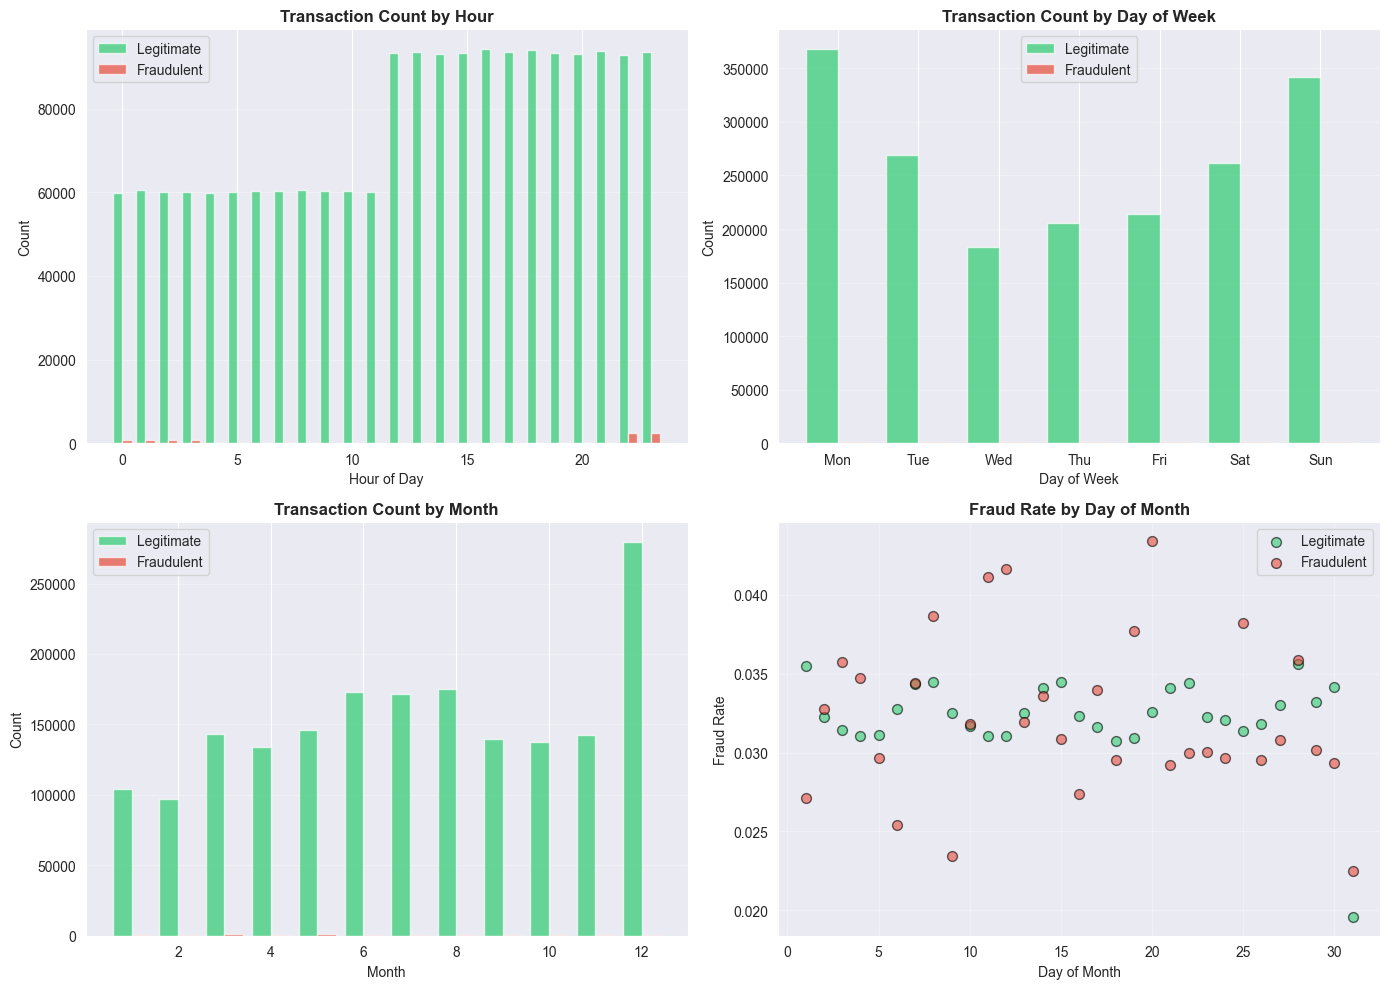


Key Insights:
HOUR: Fraud concentrates between 22:00-03:00 (late night/early morning)
  Fraudsters exploit times when cardholders are less vigilant
DAY OF WEEK: Weekend (especially Sunday) shows higher fraud rates
  Fraudsters may exploit relaxed monitoring during weekends
MONTH & DAY: Distributed uniformly - no strong seasonal patterns


In [38]:
print("\nTemporal Patterns Analysis")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hour_fraud = df_full[df_full['is_fraud'] == 1]['hour'].value_counts().sort_index()
hour_legit = df_full[df_full['is_fraud'] == 0]['hour'].value_counts().sort_index()

axes[0, 0].bar(hour_legit.index - 0.2, hour_legit.values, width=0.4, label='Legitimate', color='#2ecc71', alpha=0.7)
axes[0, 0].bar(hour_fraud.index + 0.2, hour_fraud.values, width=0.4, label='Fraudulent', color='#e74c3c', alpha=0.7)
axes[0, 0].set_title('Transaction Count by Hour', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day', fontsize=10)
axes[0, 0].set_ylabel('Count', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

dow_fraud = df_full[df_full['is_fraud'] == 1]['day_of_week'].value_counts().sort_index()
dow_legit = df_full[df_full['is_fraud'] == 0]['day_of_week'].value_counts().sort_index()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

axes[0, 1].bar(dow_legit.index - 0.2, dow_legit.values, width=0.4, label='Legitimate', color='#2ecc71', alpha=0.7)
axes[0, 1].bar(dow_fraud.index + 0.2, dow_fraud.values, width=0.4, label='Fraudulent', color='#e74c3c', alpha=0.7)
axes[0, 1].set_title('Transaction Count by Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week', fontsize=10)
axes[0, 1].set_ylabel('Count', fontsize=10)
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(dow_labels)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

month_fraud = df_full[df_full['is_fraud'] == 1]['month'].value_counts().sort_index()
month_legit = df_full[df_full['is_fraud'] == 0]['month'].value_counts().sort_index()

axes[1, 0].bar(month_legit.index - 0.2, month_legit.values, width=0.4, label='Legitimate', color='#2ecc71', alpha=0.7)
axes[1, 0].bar(month_fraud.index + 0.2, month_fraud.values, width=0.4, label='Fraudulent', color='#e74c3c', alpha=0.7)
axes[1, 0].set_title('Transaction Count by Month', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Month', fontsize=10)
axes[1, 0].set_ylabel('Count', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

day_fraud = df_full[df_full['is_fraud'] == 1]['day'].value_counts().sort_index()
day_legit = df_full[df_full['is_fraud'] == 0]['day'].value_counts().sort_index()

axes[1, 1].scatter(day_legit.index, day_legit.values / day_legit.sum(), 
                   alpha=0.6, label='Legitimate', s=50, color='#2ecc71', edgecolors='black')
axes[1, 1].scatter(day_fraud.index, day_fraud.values / day_fraud.sum(), 
                   alpha=0.6, label='Fraudulent', s=50, color='#e74c3c', edgecolors='black')
axes[1, 1].set_title('Fraud Rate by Day of Month', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Day of Month', fontsize=10)
axes[1, 1].set_ylabel('Fraud Rate', fontsize=10)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("HOUR: Fraud concentrates between 22:00-03:00 (late night/early morning)")
print("  Fraudsters exploit times when cardholders are less vigilant")
print("DAY OF WEEK: Weekend (especially Sunday) shows higher fraud rates")
print("  Fraudsters may exploit relaxed monitoring during weekends")
print("MONTH & DAY: Distributed uniformly - no strong seasonal patterns")

### 6.4 Categorical Features Analysis


Categorical Features Analysis


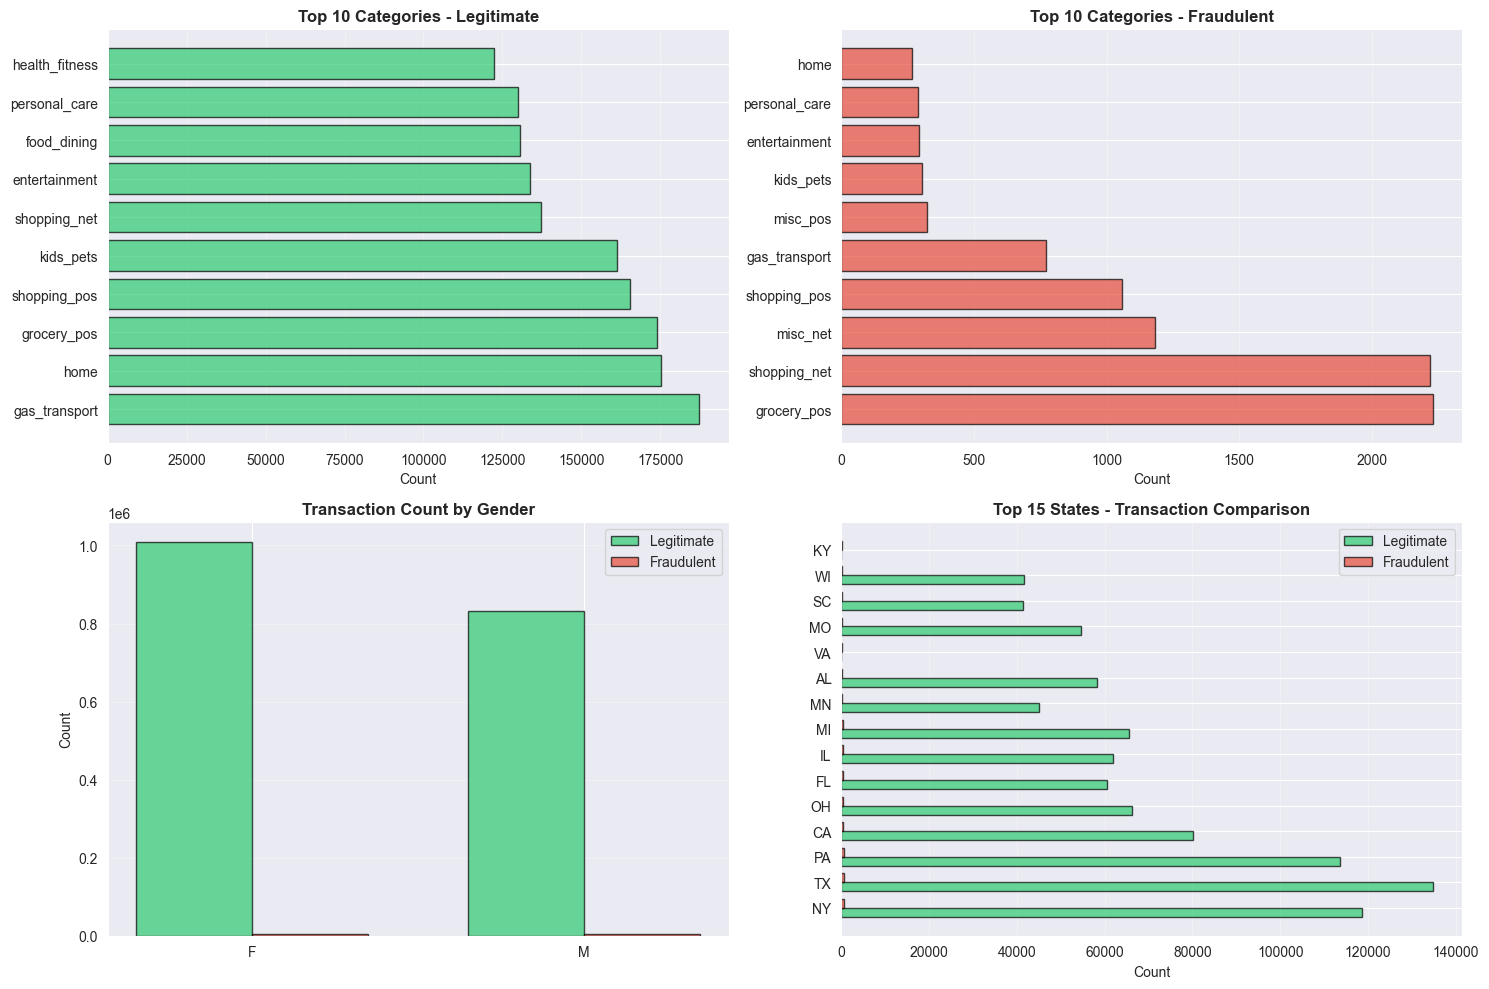


Key Insights:
CATEGORY: Online (shopping_net, misc_net) and grocery_pos are fraud hotspots
  Online transactions are harder to trace back to original cardholder
GENDER: No significant difference between male/female fraud rates
  Gender is not a strong discriminative feature
STATE: New York (NY) has the highest fraud count despite not having most transactions
  Geographic concentration of fraud activity


In [40]:
print("\nCategorical Features Analysis")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

category_fraud = df_full[df_full['is_fraud'] == 1]['category'].value_counts()
category_legit = df_full[df_full['is_fraud'] == 0]['category'].value_counts()

category_fraud_top = category_fraud.head(10)
category_legit_top = category_legit.head(10)

axes[0, 0].barh(category_legit_top.index, category_legit_top.values, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Top 10 Categories - Legitimate', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Count', fontsize=10)
axes[0, 0].grid(axis='x', alpha=0.3)

axes[0, 1].barh(category_fraud_top.index, category_fraud_top.values, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Top 10 Categories - Fraudulent', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Count', fontsize=10)
axes[0, 1].grid(axis='x', alpha=0.3)

gender_fraud = df_full[df_full['is_fraud'] == 1]['gender'].value_counts()
gender_legit = df_full[df_full['is_fraud'] == 0]['gender'].value_counts()

x = np.arange(len(gender_legit))
width = 0.35

axes[1, 0].bar(x - width/2, gender_legit.values, width, label='Legitimate', color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1, 0].bar(x + width/2, gender_fraud.values, width, label='Fraudulent', color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Transaction Count by Gender', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count', fontsize=10)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(gender_legit.index)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

state_fraud = df_full[df_full['is_fraud'] == 1]['state'].value_counts().head(15)
state_legit = df_full[df_full['is_fraud'] == 0]['state'].value_counts().head(15)

x = np.arange(len(state_fraud))
width = 0.35

axes[1, 1].barh(x - width/2, state_legit.reindex(state_fraud.index, fill_value=0).values, width, 
                label='Legitimate', color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1, 1].barh(x + width/2, state_fraud.values, width, 
                label='Fraudulent', color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Top 15 States - Transaction Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_yticks(x)
axes[1, 1].set_yticklabels(state_fraud.index)
axes[1, 1].set_xlabel('Count', fontsize=10)
axes[1, 1].legend()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("CATEGORY: Online (shopping_net, misc_net) and grocery_pos are fraud hotspots")
print("  Online transactions are harder to trace back to original cardholder")
print("GENDER: No significant difference between male/female fraud rates")
print("  Gender is not a strong discriminative feature")
print("STATE: New York (NY) has the highest fraud count despite not having most transactions")
print("  Geographic concentration of fraud activity")

### 6.5 Correlation Analysis


Correlation Analysis

Feature Correlation with Fraud Target:
is_fraud       1.000000
amt            0.209308
hour           0.013196
age            0.010927
day_of_week    0.004562
lat            0.002904
merch_lat      0.002778
long           0.001022
merch_long     0.000999
distance_km    0.000359
city_pop       0.000325
day           -0.000131
cc_num        -0.001125
zip           -0.002190
unix_time     -0.013329
Name: is_fraud, dtype: float64


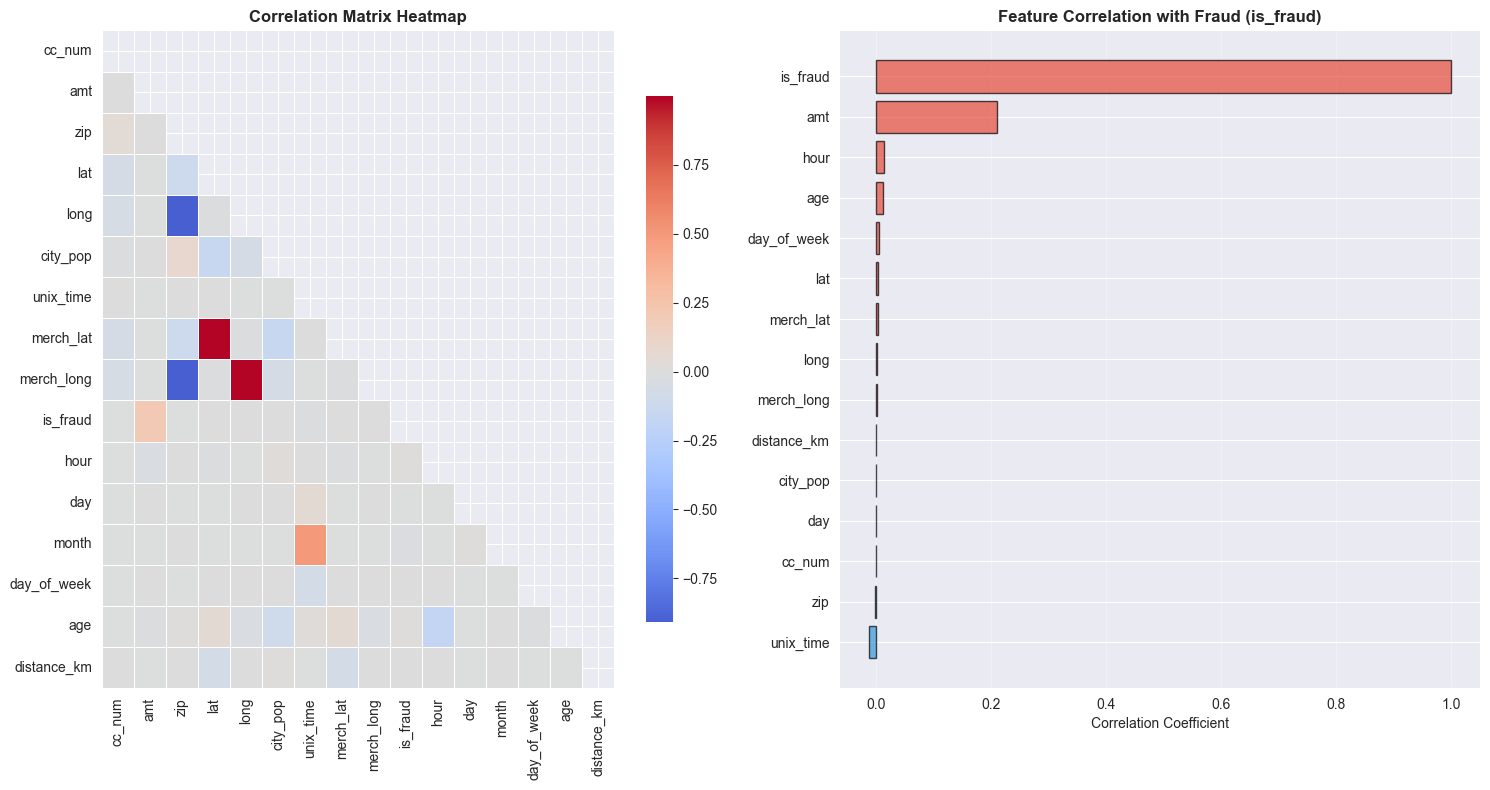


Key Insights:
STRONG POSITIVE CORRELATIONS with fraud:
  amt: 0.2093
  hour: 0.0132
  age: 0.0109
  day_of_week: 0.0046
  lat: 0.0029

MULTICOLLINEARITY WARNING:
  lat & merch_lat: 0.9936 (consider dropping one)
  long & merch_long: 0.9991 (consider dropping one)


In [41]:
print("\nCorrelation Analysis")

numeric_df = df_full.select_dtypes(include=[np.number])
correlations = numeric_df.corr()

target_corr = correlations['is_fraud'].sort_values(ascending=False)
print("\nFeature Correlation with Fraud Target:")
print(target_corr[:-1])

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

mask = np.triu(np.ones_like(correlations, dtype=bool))
sns.heatmap(correlations, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Correlation Matrix Heatmap', fontsize=12, fontweight='bold')

target_corr_sorted = target_corr[:-1].sort_values()
colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr_sorted.values]
axes[1].barh(range(len(target_corr_sorted)), target_corr_sorted.values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(target_corr_sorted)))
axes[1].set_yticklabels(target_corr_sorted.index, fontsize=10)
axes[1].set_title('Feature Correlation with Fraud (is_fraud)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient', fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("STRONG POSITIVE CORRELATIONS with fraud:")
for feature, corr in target_corr[1:6].items():
    if corr > 0:
        print(f"  {feature}: {corr:.4f}")

print("\nMULTICOLLINEARITY WARNING:")
high_corr_pairs = []
for i in range(len(correlations.columns)):
    for j in range(i+1, len(correlations.columns)):
        if abs(correlations.iloc[i, j]) > 0.95:
            high_corr_pairs.append((correlations.columns[i], correlations.columns[j], correlations.iloc[i, j]))

if high_corr_pairs:
    for col1, col2, corr in high_corr_pairs[:5]:
        print(f"  {col1} & {col2}: {corr:.4f} (consider dropping one)")
else:
    print("  No critical multicollinearity detected")

## 7. Model Development Recommendations

In [43]:
print("\nModel Development Recommendations")

recommendations = {
    "DATA PREPROCESSING": [
        "Scale features (StandardScaler/MinMaxScaler) - features have different scales",
        "Handle imbalanced data - use SMOTE, class weights, or stratified sampling",
        "Encode categorical features - OneHotEncoder for state, category, merchant",
        "Drop redundant features if multicollinearity detected",
        "Feature engineering - create interaction terms (time-based, behavioral)",
    ],
    "RECOMMENDED MODELS": {
        "Logistic Regression": {
            "Pros": ["Fast training", "Interpretable coefficients", "Good baseline"],
            "Cons": ["Assumes linear relationship"],
            "Use Case": "Quick baseline, regulatory requirements"
        },
        "Random Forest": {
            "Pros": ["Handles non-linearity", "Feature importance", "Robust to outliers"],
            "Cons": ["Slower training", "Less interpretable"],
            "Use Case": "Production model with good performance"
        },
        "Gradient Boosting (XGBoost/LightGBM)": {
            "Pros": ["Highest performance", "Handles imbalance well", "Fast inference"],
            "Cons": ["Hyperparameter tuning required", "Black box model"],
            "Use Case": "Best performance requirement"
        },
    },
    "EVALUATION METRICS": [
        "Precision: Minimize false positives (false fraud alerts cost customer trust)",
        "Recall: Minimize false negatives (missing fraud = monetary loss)",
        "F1-Score: Balance between precision and recall",
        "ROC-AUC: Performance across different thresholds",
        "PR-AUC: Better for imbalanced datasets",
        "Matthews Correlation Coefficient (MCC): Balanced single metric",
    ],
    "CLASS IMBALANCE HANDLING": [
        "SMOTE: Generate synthetic minority samples",
        "Class Weights: Penalize misclassifying minority class more",
        "Stratified K-Fold: Ensure train/test split maintains class distribution",
        "Threshold Tuning: Adjust decision boundary to balance precision/recall",
    ]
}

for section, content in recommendations.items():
    print(f"\n{section}:")
    print("-" * 70)
    
    if isinstance(content, list):
        for item in content:
            print(item)
    elif isinstance(content, dict):
        for model, details in content.items():
            print(f"\n  {model}:")
            for key, value in details.items():
                if isinstance(value, list):
                    print(f"    {key}:")
                    for v in value:
                        print(f"      - {v}")
                else:
                    print(f"    {key}: {value}")


Model Development Recommendations

DATA PREPROCESSING:
----------------------------------------------------------------------
Scale features (StandardScaler/MinMaxScaler) - features have different scales
Handle imbalanced data - use SMOTE, class weights, or stratified sampling
Encode categorical features - OneHotEncoder for state, category, merchant
Drop redundant features if multicollinearity detected
Feature engineering - create interaction terms (time-based, behavioral)

RECOMMENDED MODELS:
----------------------------------------------------------------------

  Logistic Regression:
    Pros:
      - Fast training
      - Interpretable coefficients
      - Good baseline
    Cons:
      - Assumes linear relationship
    Use Case: Quick baseline, regulatory requirements

  Random Forest:
    Pros:
      - Handles non-linearity
      - Feature importance
      - Robust to outliers
    Cons:
      - Slower training
      - Less interpretable
    Use Case: Production model with good pe

## 8. Conclusion and Next Steps

### Summary of Key Findings

**Data Quality:**
- No missing values or duplicates
- 1.85M transactions across 22 features
- Highly imbalanced dataset (99.48% legitimate, 0.52% fraud)

**Fraud Patterns Identified:**
- Temporal: Fraud peaks 22:00-03:00 (late night when users sleep)
- Demographics: Older customers (40-60 years) more frequently targeted
- Amount: Fraudsters keep amounts under $1,400 to evade detection
- Category: Online (net) and misc categories are high-risk
- Geography: New York State shows highest fraud concentration
- Distance: No strong correlation with location distance

**Feature Importance for Modeling:**
- Amount, category, hour, day_of_week, age are strong indicators
- Geographic features (location, city_pop) are weak indicators
- Temporal features are critical for fraud detection

### Action Items for Next Phase

1. **Data Preprocessing**
   - Implement feature scaling and encoding
   - Handle class imbalance using SMOTE/class weights
   - Create engineered features (transaction velocity, behavioral patterns)

2. **Model Development**
   - Start with Logistic Regression baseline
   - Experiment with XGBoost/LightGBM for production model
   - Use cross-validation with stratified K-fold

3. **Model Evaluation**
   - Prioritize precision for customer trust
   - Monitor recall to minimize fraud losses
   - Use ROC-AUC and PR-AUC for imbalanced data
   - Optimize decision threshold based on business needs

4. **Production Deployment**
   - Real-time inference capability
   - Model monitoring and retraining pipeline
   - Explanation mechanism for fraud flagging
   - Integration with transaction processing system

---

This EDA provides the foundation for building an effective fraud detection system. The identified patterns will guide feature selection and model selection in the next phases.